# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`

## `Задание 02. Сегментация изображений`

#### Фамилия, имя:

Дата выдачи: <span style="color:red">__6 марта__</span>.

Мягкий дедлайн: <span style="color:red">__21 марта 3:00__</span>.

Стоимость: __10 баллов__ (основная часть заданий) + __4.25 балла__ (дополнительные задания).

<span style="color:red">__В ноутбуке все клетки должны выполняться без ошибок при последовательном их выполнении.__</span>

#### `Москва, 2026`

В этом задании вы будете решать задачу сегментации людей на фотографии с помощью нейросетевых архитектур `U-Net` и `LinkNet`.

Данные для выполнения задания можно скачать по [ссылке](https://disk.yandex.ru/d/tI6d3LBMHTwOnw).

## `Загрузка данных (1 балл)`

Для загрузки данных pytorch опирается на такую сущность, как **`Dataset`**.

Этот абстрактный класс определен в `torch.utils.data.dataset`:

```python
class Dataset(object):
    """An abstract class representing a Dataset.

    All other datasets should subclass it. All subclasses should override
    ``__len__``, that provides the size of the dataset, and ``__getitem__``,
    supporting integer indexing in range from 0 to len(self) exclusive.
    """

    def __getitem__(self, index):
        raise NotImplementedError

    def __len__(self):
        raise NotImplementedError

    def __add__(self, other):
        return ConcatDataset([self, other])
```
При определении нового источника данных мы создаем наследника данного класса и реализуем методы `__getitem__` и `__len__`.

Пример готового такого класса — `torchvision.datasets.ImageFolder`, который позволяет создать датасет на основе директории с ImageNet-подобной структурой поддиректорий (`./train/{class}` и `./val/{class}`):

```python
imagenet = torchvision.datasets.ImageFolder('path/to/imagenet_root/')
```

Реализуйте класс `PhotosDataset` для выданных данных.

**Внимание.** Возможно, стоит прочитать следующий пункт задания, чтобы реализация была удобной.

In [5]:
!pip install comet-ml -q

In [6]:
import os
import random

import numpy as np
import numpy.testing as npt

import comet_ml
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models import vgg13, VGG13_Weights
from torchvision import transforms

import matplotlib_inline
import matplotlib.pyplot as plt

from PIL import Image

%matplotlib inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf', 'svg')

In [7]:
class PhotosDataset(Dataset):
    def __init__(self, images_dir, target_dir=None, transforms=None):
        super().__init__()
        self.images_dir = images_dir
        self.target_dir = target_dir
        self.transforms = transforms if transforms is not None else []

        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(target_dir)) if target_dir is not None else None

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        img = Image.open(img_path).convert("RGB")

        mask = None
        if self.masks is not None:
            mask_path = os.path.join(self.target_dir, self.masks[idx])
            mask = Image.open(mask_path)

        for transform in self.transforms:
            if mask is not None:
                img, mask = transform(img, mask)
            else:
                img = transform(img)

        if mask is not None:
            return img, mask
        return img

## `Модуль аугментации (2 балла)`

Конструктор стандартного `ImageFolder`, принимает параметр `transform` (и иногда `target_transform`).

Они служат для того, чтобы загружаемые изображения (обычно это `PIL.Image`) или таргеты преобразовывать в тензоры нужного вида.

В `torchvision` входит модуль `transforms` для стандартных примеров таких преобразований. В `transforms` могут содержаться случайные преобразования, это самый простой путь для реализации аугментации данных.

При определении кастомного трансформера помимо конструктора нужно реализовать лишь метод `__call__`:

```python
class HorizontalFlip(object):
    def __init__(self, mode=0):
        self.method = mode

    def __call__(self, img):
        """
        Args:
            img (PIL.Image): Image to be flipped.

        Returns:
            PIL.Image: Randomly flipped image.
        """
        if self.method:
            return img.transpose(Image.FLIP_LEFT_RIGHT)
        return img

```

С полным списком стандартных преобразований можно ознакомиться в [документации](https://pytorch.org/vision/0.12/transforms.html).

В данной части вам предлагается самостоятельно реализовать несколько кастомных трансформеров.
Обратите внимание, что для некоторых трансформеров, необходимо преобразовывать и изображение, и маску, а для каких-то только изображение.

Один из путей реализации:
* реализовать декоратор, делающий любое преобразование случайным
* реализовать декоратор, применяющий преобразование и к изображению, и к маске

Список трансформеров, которые надо реализовать:

1. случайное (с вероятностью $p$) горизонтальное отображение (flip) изображения
2. случайное (с вероятностью $p$) вырезание фрагмента изображения (заданного или случайного размера)
3. случайное (с вероятностью $p$) изменение яркости изображения (на заданную или случайную величину)
4. случайное (с вероятностью $p$) изменение фона изображения (на изображение из заданного списка изображений)

Используйте разумные пределы для аугментаций. Одной из причин плохого обучения модели могут быть слишком сильные аугментации. Визуально убедитесь, что граничные случаи достаточно адекватны задаче.

Обратите внимание, что под вырезанием фрагмента подразумевается вырезания части изображения из исходного, то есть вырезание какой-то части изображения (создание отверстий в изображении). Если после слоя вырезания размеры изображения поменялись, то вы неправильно реализовали модуль. Это преобразование известно как [RandomErasing](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.RandomErasing.html).

**Внимание.** Вы должны самостоятельно реализовать аугментации, а не использовать готовые функции.

*Примечание:* В аугментации 4, вы сами выбираете какой фон, достаточно 10 изображений найденных из любых источников, которые можно назвать фоном. В аугментациях 2 и 3 подразумевается реализация и заданной величины и константы, код должен уметь обрабатывать оба случая.

In [8]:
def random_apply(p):
    def decorator(func):
        def wrapper(self, *args, **kwargs):
            if random.random() < p:
                return func(self, *args, **kwargs)
            if len(args) == 1:
                return args[0]#, args[1]
            return args[0], args[1]
        return wrapper
    return decorator

In [9]:
class HorizontalFlip(object):
    def __init__(self):
      pass

    @random_apply(p=0.5)
    def __call__(self, img, mask=None):
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
        if mask is not None:
            mask = mask.transpose(Image.FLIP_LEFT_RIGHT)
        if mask is None:
            return img
        return img, mask

In [10]:
class PartErase(object):
    def __init__(self, w=None, h=None):
        self.w = w
        self.h = h

    @random_apply(p=0.5)
    def __call__(self, img, mask=None):
        width, height = img.size

        if self.w is not None and self.h is not None:
          left = random.randint(0, width - self.w)
          top = random.randint(0, height - self.h)
          black = Image.new("RGB", (self.w, self.h), (0, 0, 0))
        else:
          r_w, r_h = random.randint(5, width // 2), random.randint(5, height // 2)
          left = random.randint(0, width - r_w)
          top = random.randint(0, height - r_h)
          black = Image.new("RGB", (r_w, r_h), (0, 0, 0))

        img_c = img.copy()
        img_c.paste(black, (left, top))

        if mask is not None:
          return img_c, mask

        return img_c

In [11]:
class RandomBrightness(object):
    def __init__(self, factor=None, min_factor=0.2, max_factor=2.0):
        self.factor = factor
        self.min_factor = min_factor
        self.max_factor = max_factor

    @random_apply(p=0.5)
    def __call__(self, img, mask=None):
        factor = self.factor if self.factor is not None else random.uniform(self.min_factor, self.max_factor)

        arr = np.array(img, dtype=np.float32)
        arr = np.clip(arr * factor, 0, 255).astype(np.uint8)
        img_bright = Image.fromarray(arr)

        if mask is not None:
            return img_bright, mask

        return img_bright


In [12]:
class RandomBackground(object):
    def __init__(self, backgrounds):
        self.backgrounds = backgrounds

    @random_apply(p=0.5)
    def __call__(self, img, mask=None):
        if mask is None:
            return img

        bg_path = random.choice(self.backgrounds)
        bg = Image.open(bg_path).resize(img.size).convert("RGB")

        img_arr = np.array(img, dtype=np.uint8)
        bg_arr = np.array(bg, dtype=np.uint8)
        mask_arr = np.array(mask, dtype=np.uint8)

        if mask_arr.ndim == 2:
            fg = (mask_arr > 0)[:, :, np.newaxis]
        else:
            fg = (mask_arr[:, :, 0] > 0)[:, :, np.newaxis]

        result = np.where(fg, img_arr, bg_arr).astype(np.uint8)
        return Image.fromarray(result), mask

Добавьте случайные преобразования в ваши датасеты. Также, добавьте преобразование в tensor и нормализацию для изображения:

```python
transforms.ToTensor()
transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)
```

In [13]:
class ToTensor(object):
    def __call__(self, image, mask=None):
        img_tensor = transforms.ToTensor()(image)
        if mask is None:
            return img_tensor
        mask_tensor = (torch.from_numpy(np.array(mask, dtype=np.int64)) / 255).float() # [H,W] long
        return img_tensor, mask_tensor

class Normalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, image, mask):
        return transforms.Normalize(mean=self.mean, std=self.std)(image), mask

In [14]:
DATA_PATH = "/kaggle/input/datasets/bilbul184/people-data/people_data" # your path


In [15]:
BACKGROUNDS = "/kaggle/input/datasets/bilbul184/backgrounds/backgrounds"


In [16]:
background_files = [os.path.join(BACKGROUNDS, fname) for fname in os.listdir(BACKGROUNDS)]

train_dataset = PhotosDataset(
    images_dir=os.path.join(DATA_PATH, 'train'),
    target_dir=os.path.join(DATA_PATH, 'train_mask'),
    transforms=[
        HorizontalFlip(),
        PartErase(),
        RandomBrightness(),
        RandomBackground(background_files),
        ToTensor(),
        Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])


test_dataset = PhotosDataset(
    images_dir=os.path.join(DATA_PATH, 'test'),
    target_dir=os.path.join(DATA_PATH, 'test_mask'),
    transforms=[
        ToTensor(),
        Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])

Функция для отображения изображения:

In [17]:
def show_idx_image(dataset, idx):
    image, mask = dataset[idx]

    image = image.permute(1, 2, 0).numpy()
    image = (image * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    image = np.clip(image, 0, 1)

    mask = mask.squeeze(0).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    axes[0].imshow(image)
    axes[1].imshow(mask)

    axes[0].set_axis_off()
    axes[1].set_axis_off()

    fig.tight_layout()
    plt.show()

Отобразите несколько изображений и масок, на которых будет видна правильная работа вашего модуля аугментации данных. Необходимо проверить каждый модуль аугментации отдельно, в ином случае будут сниматься баллы.

**Важно:** Проверьте корректность работы модулей, действительно ли маска изображения корректна для изображения после аугментации.

In [18]:
img, mask = train_dataset[262]
print(type(img))

<class 'torch.Tensor'>


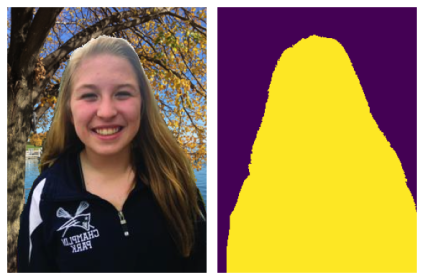

In [19]:
show_idx_image(train_dataset, 169)

## HorizontalFlip

In [20]:
train_dataset = PhotosDataset(
    images_dir=os.path.join(DATA_PATH, 'train'),
    target_dir=os.path.join(DATA_PATH, 'train_mask'),
    transforms=[
        HorizontalFlip(),
        ToTensor(),
        Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])

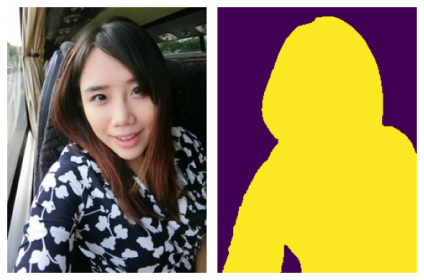

In [21]:
show_idx_image(train_dataset, 55)

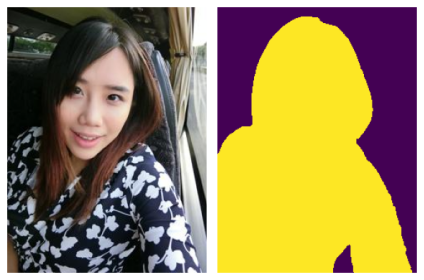

In [22]:
show_idx_image(train_dataset, 55)

## PartErase

In [23]:
train_dataset = PhotosDataset(
    images_dir=os.path.join(DATA_PATH, 'train'),
    target_dir=os.path.join(DATA_PATH, 'train_mask'),
    transforms=[
        PartErase(),
        ToTensor(),
        Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])

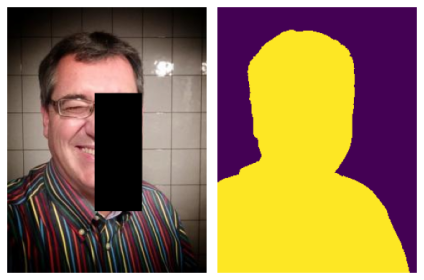

In [24]:
show_idx_image(train_dataset, 67)

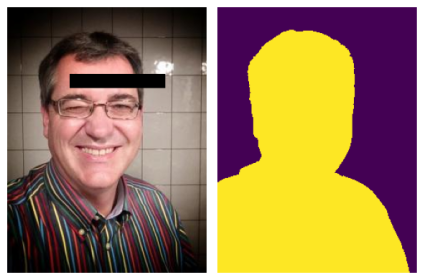

In [25]:
show_idx_image(train_dataset, 67)

## RandomBrightness

In [26]:
train_dataset = PhotosDataset(
    images_dir=os.path.join(DATA_PATH, 'train'),
    target_dir=os.path.join(DATA_PATH, 'train_mask'),
    transforms=[
        RandomBrightness(),
        ToTensor(),
        Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])

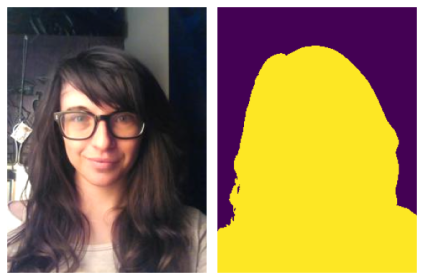

In [27]:
show_idx_image(train_dataset, 167)

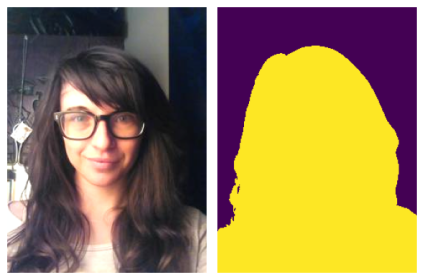

In [28]:
show_idx_image(train_dataset, 167)

## RandomBackground

In [29]:
train_dataset = PhotosDataset(
    images_dir=os.path.join(DATA_PATH, 'train'),
    target_dir=os.path.join(DATA_PATH, 'train_mask'),
    transforms=[
        RandomBackground(background_files),
        ToTensor(),
        Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])

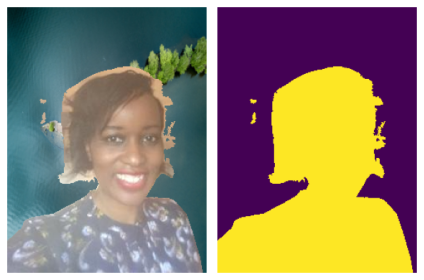

In [30]:
show_idx_image(train_dataset, 203)

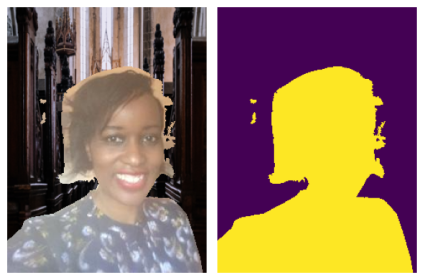

In [31]:
show_idx_image(train_dataset, 203)

## `Загрузчики`

При обучении сети удобнее работать не с датасетами, а с загрузчиками. Загрузчики создаются на основе датасета и позволяют итерироваться по батчам из него.

Обратите внимание на параметры `DataLoader`. При `num_workers`$\;> 1$, батчи готовятся (загружаются картинки, обрабатываются и так далее) сразу в нескольких фоновых процессах. С помощью параметра `shuffle` можно подавать картинки на обучение в случайном порядке.

Обычно, скорость обработки данных на GPU превышает скорость загрузки данных в одном процессе, поэтому типичное значение для `num_workers`$\approx 3\text{-}10$.

Учтите, что на некоторых системах в Jupyter Notebook при `num_workers`$>0$ `DataLoader` перестаёт работать. В таком случае установите это значение в $0$.

In [32]:
test_data_loader = DataLoader(test_dataset, batch_size=8, num_workers=3)
train_data_loader = DataLoader(train_dataset, batch_size=8, num_workers=3, shuffle=True)

## `DiceLoss (1 балл)`

Функция потерь реализовывается как и все стандартные нейронные модули в pytorch, через `torch.nn.Module`. В ячейке ниже вам предлагается реализовать функцию потерь `dice` (аналог меры Жаккарда).

Результат **Dice Loss** определим как:

$$
\text{Dice Coefficient} = 2\frac{|A \cap B| }{|A| + |B|} \leadsto \text{Dice Loss} = 1 - \frac{2\sum\limits_{i, j}a_{ij}b_{ij}}{\sum\limits_{ij}(a_{ij} + b_{ij} + \varepsilon)}
$$

где $a_{ij} \in [0, 1]$ — предсказанная вероятность нахождения человека в пикселе изображения, $b_{ij}$ — истинная разметка для пикселя изображения.

In [33]:
class DiceLoss(torch.nn.Module):
    def __init__(self, eps=1e-7, reduction=None, with_logits=True):
        """
        Arguments
        ---------
        eps : float
            eps in denominator
        reduction : Optional[str] (None, 'mean' or 'sum')
            specifies the reduction to apply to the output:

            None: no reduction will be applied
            'mean': the sum of the output will be divided by the number of elements in the batch
            'sum':  the output will be summed.
        with_logits : bool
            If True, use additional sigmoid for inputs
        """
        super().__init__()
        self.eps = eps
        self.reduction = reduction
        self.with_logits = with_logits

    def forward(self, logits, true_labels):
        """
        Arguments
        ---------
        logits: torch.Tensor
            Unnormalized probability of true class. Shape: [B, ...]
        true_labels: torch.Tensor
            Mask of correct predictions. Shape: [B, ...]
        Returns
        -------
        torch.Tensor
            If reduction is 'mean' or 'sum' returns a tensor with a single element
            Otherwise, returns a tensor of shape [B]
        """
        # true_labels = true_labels.to(torch.long)

        if self.with_logits:
            probs = torch.sigmoid(logits)
        else:
            probs = logits

        B = probs.shape[0]
        probs = probs.view(B, -1)
        true_labels = true_labels.view(B, -1)

        numerator = 2 * (probs * true_labels).sum(dim=1)
        denominator = (probs + true_labels).sum(dim=1) + self.eps
        dice_loss = 1 - numerator / denominator

        if self.reduction == 'sum':
            # your code here
            loss_value = dice_loss.sum()
        elif self.reduction == 'mean':
            # your code here
            loss_value = dice_loss.mean()
        elif self.reduction is None:
            # your code here
            loss_value = dice_loss

        return loss_value

Проверка реализации:

In [34]:
logits = torch.tensor([
    [[0, 0.5], [0.5, 1]],
    [[0.1, 0.1], [0, 0]],
])

target = torch.tensor([
    [[0, 1], [1, 1]],
    [[1, 0], [0, 1]],
])

losses = DiceLoss(with_logits=False, reduction=None, eps=1e-7)(logits, target)
npt.assert_almost_equal(losses.numpy(), np.array([0.2, 0.90909]), decimal=4)

loss = DiceLoss(with_logits=False, reduction='mean', eps=1e-7)(logits, target)
npt.assert_almost_equal(float(loss.numpy()), 0.554545, decimal=4)

loss = DiceLoss(with_logits=False, reduction='sum', eps=1e-7)(logits, target)
npt.assert_almost_equal(float(loss.numpy()), 1.10909, decimal=4)

## `U-Net (3 балла)`

Для решения задачи сегментации будем использовать [U-Net](https://arxiv.org/pdf/1505.04597.pdf) с энкодером из первых блоков предобученного `VGG13`.

Концептуальная схема представлена на диаграмме ниже:

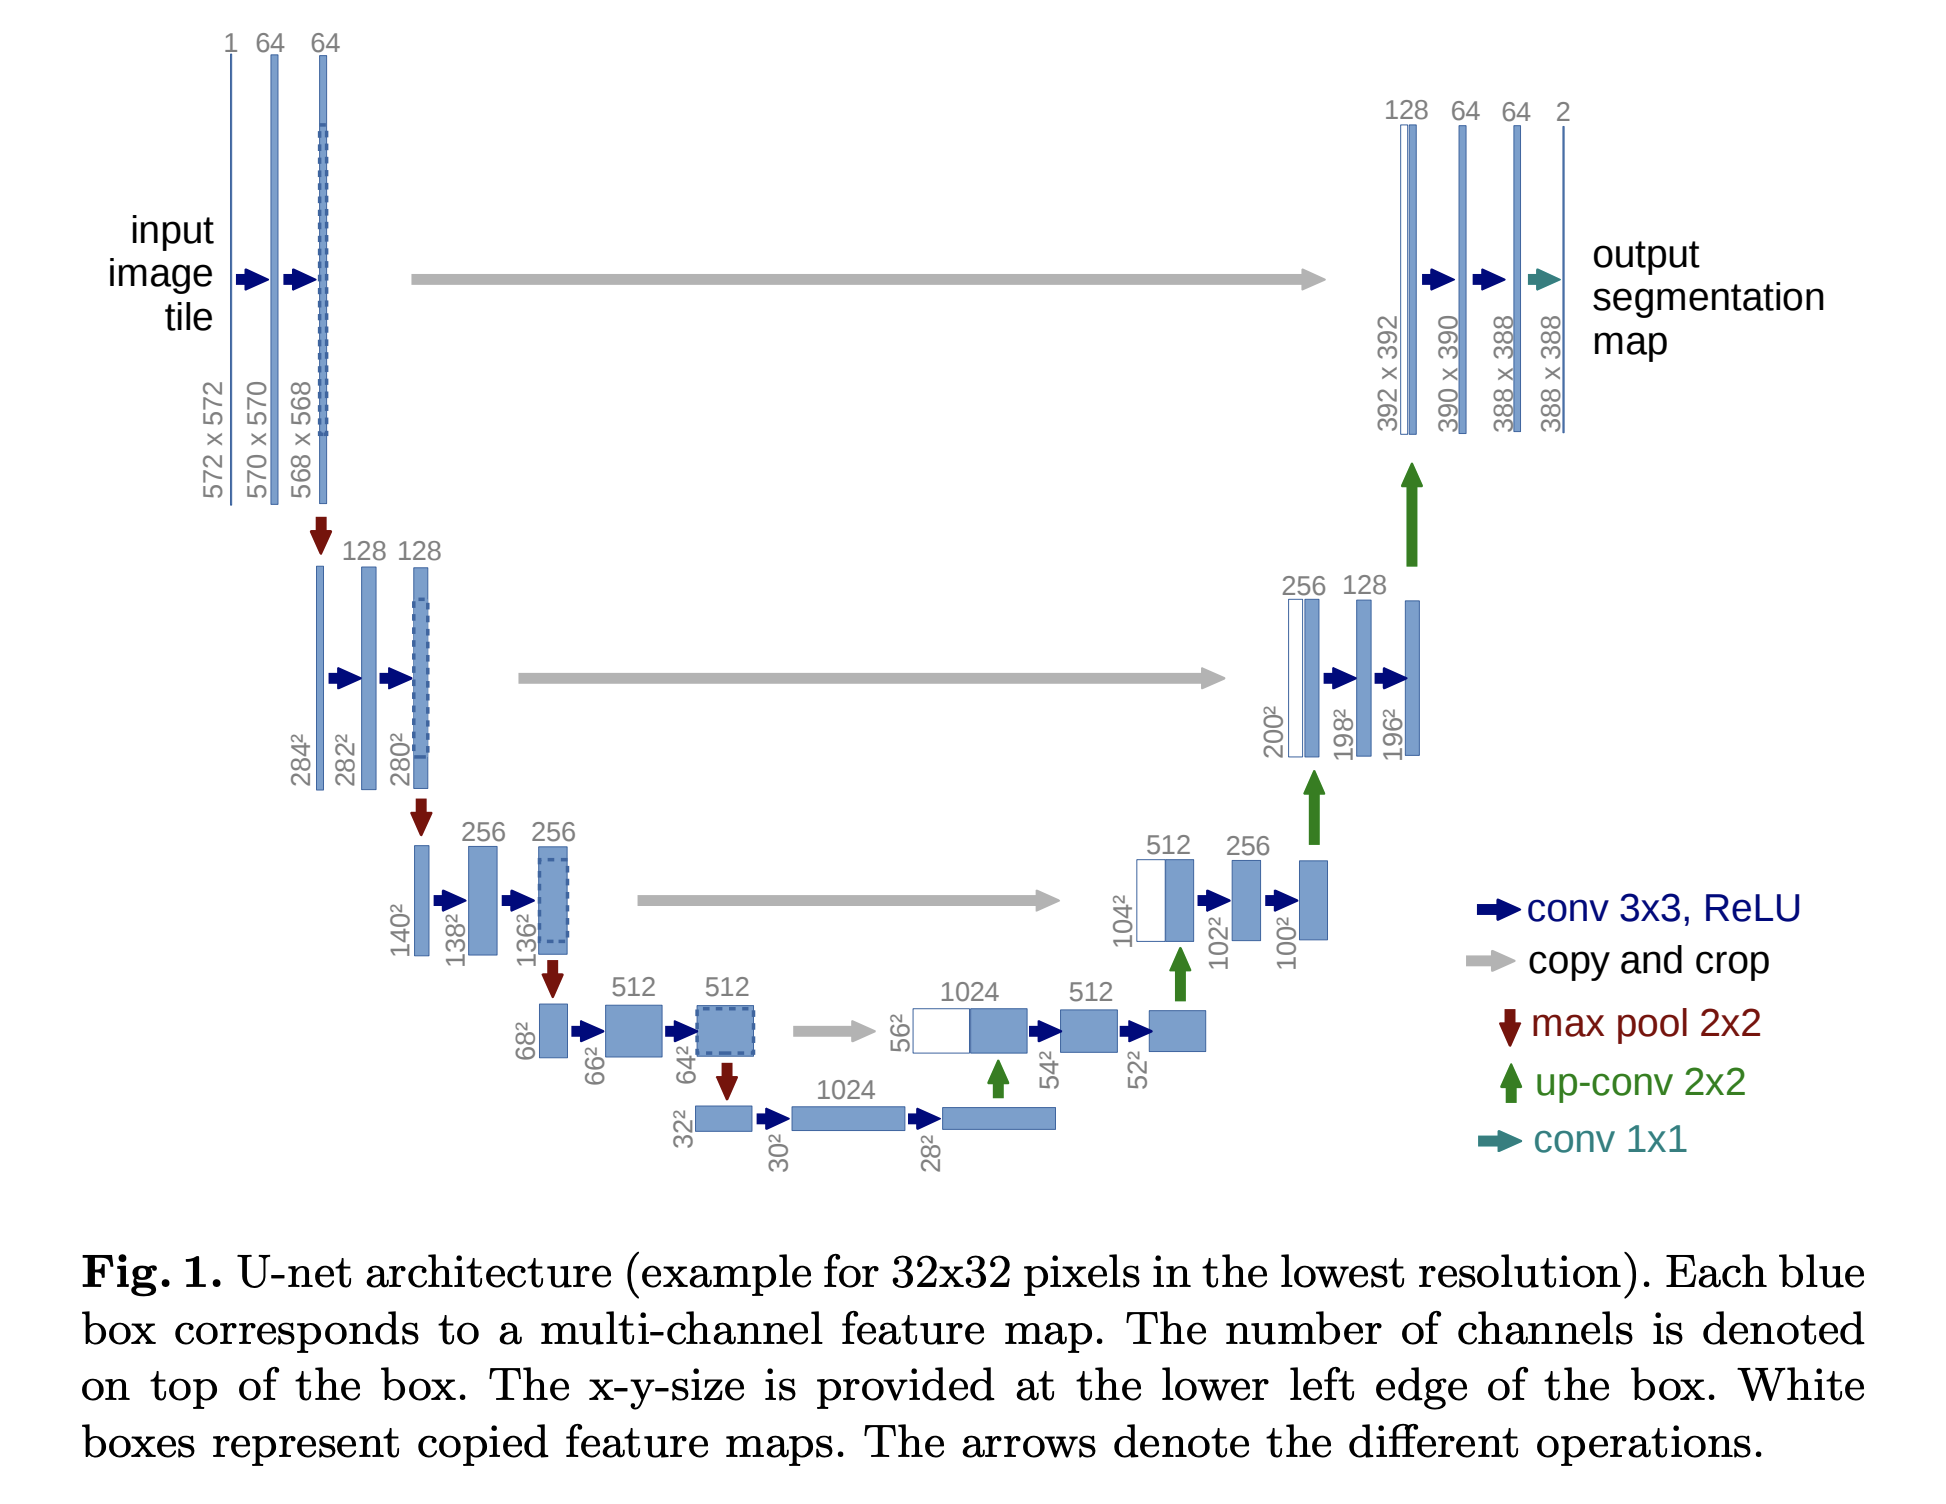

Заметим, что блоки VGG13 имеют следующий вид:
```python
    (0): Conv2d(...)
    (1): ReLU(...)
    (2): Conv2d(...)
    (3): ReLU(...)
    (4): MaxPool2d(...)
```

Для удобства, уберём слои `MaxPool2d` из блоков энкодера и будем применять pooling отдельно. Возможно, вам будет полезно вывести архитектуру модели `VGG` и изучить параметры слоев pooling.

При реализации `Decoder` вам пригодится интерполяция, для этого можно использовать `torch.nn.functional.interpolate` с `mode=nearest`.

Реализуйте архитектуру данной сети.

#### `Encoder`

In [35]:
class VGG13Encoder(torch.nn.Module):
    def __init__(self, num_blocks, weights=VGG13_Weights.DEFAULT):
        super().__init__()
        self.num_blocks = num_blocks

        # Будем использовать предобученную VGG13 в качестве backbone
        feature_extractor = vgg13(weights=weights).features

        # Каждый блок энкодера U-Net — это блок VGG13 без MaxPool2d
        self.blocks = torch.nn.ModuleList()
        for idx in range(self.num_blocks):
            # Возьмите нужные слои из `feature_extractor` для очередного U-Net блока
            # Объедините их с помощью `torch.nn.Sequential`
            self.blocks.append(
                # your code here
                torch.nn.Sequential(
                    *[feature_extractor[idx * 5 + i] for i in range(4)]
                )
            )

    def forward(self, x):
        activations = []
        for idx, block in enumerate(self.blocks):
            # Примените очередной блок U-Net
            # your code here
            x = block(x)

            # Сохраните активации для передачи их в декодер
            # your code here
            activations.append(x)

            # При необходимости примените max-pool
            # Можно использовать `torch.functional.F.max_pool2d`
            # your code here
            if idx < self.num_blocks - 1:
                x = torch.nn.functional.max_pool2d(x, kernel_size=2, stride=2)

        return activations

In [36]:
assert sum((param.numel() for param in VGG13Encoder(num_blocks=1).parameters())) == 38720
assert sum((param.numel() for param in VGG13Encoder(num_blocks=2).parameters())) == 260160
assert sum((param.numel() for param in VGG13Encoder(num_blocks=3).parameters())) == 1145408

x = torch.arange(1 * 3 * 320 * 240).reshape(1, 3, 320, 240) / (1 * 3 * 320 * 240)
out = VGG13Encoder(num_blocks=3)(x)

assert len(out) == 3
npt.assert_almost_equal(torch.linalg.norm(out[0]).item(), 902.218, decimal=3)
npt.assert_almost_equal(torch.linalg.norm(out[1]).item(), 571.030, decimal=3)
npt.assert_almost_equal(torch.linalg.norm(out[2]).item(), 648.068, decimal=3)

Downloading: "https://download.pytorch.org/models/vgg13-19584684.pth" to /root/.cache/torch/hub/checkpoints/vgg13-19584684.pth


100%|██████████| 508M/508M [00:02<00:00, 211MB/s]  


#### `Decoder`

In [37]:
class DecoderBlock(torch.nn.Module):
    def __init__(self, out_channels):
        super().__init__()

        self.upconv = torch.nn.Conv2d(
            in_channels=out_channels * 2, out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.conv1 = torch.nn.Conv2d(
            in_channels=out_channels * 2, out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.conv2 = torch.nn.Conv2d(
            in_channels=out_channels, out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.relu = torch.nn.ReLU()

    def forward(self, down, left):
        # Upsample x2 и свёртка
        # your code here
        x = torch.nn.functional.interpolate(down, scale_factor=2, mode='nearest')
        x = self.relu(self.upconv(x))

        # Конкатенация выхода энкодера и предыдущего блока декодера
        # your code here
        x = torch.cat([x, left], dim=1)

        # Две свёртки с ReLu
        # your code here
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))

        return x

In [38]:
class Decoder(torch.nn.Module):
    def __init__(self, num_filters, num_blocks):
        super().__init__()

        self.blocks = torch.nn.ModuleList()
        for idx in range(num_blocks):
            self.blocks.insert(0, DecoderBlock(num_filters * 2 ** idx))

    def forward(self, acts):
        up = acts[-1]
        for block, left in zip(self.blocks, acts[-2::-1]):
            up = block(up, left)
        return up

#### `U-Net`

In [39]:
class UNet(torch.nn.Module):
    def __init__(self, num_classes=1, num_blocks=4):
        super().__init__()
        # your code here
        self.encoder = VGG13Encoder(num_blocks=num_blocks)

        # your code here
        self.decoder = Decoder(num_filters=64, num_blocks=num_blocks - 1)

        # Свёртка 1x1 для попиксельной агрегации каналов
        # your code here
        self.final = torch.nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=1)


    def forward(self, x):
        # your code here
        activations = self.encoder(x)

        x = self.decoder(activations)
        x = self.final(x)

        return x

In [40]:
model = UNet(num_classes=1, num_blocks=3)
x = torch.arange(1 * 3 * 320 * 240).reshape(1, 3, 320, 240) / (1 * 3 * 320 * 240)

assert sum((param.numel() for param in model.parameters())) == 2067649
assert list(model(x).shape) == [1, 1, 320, 240]
model

UNet(
  (encoder): VGG13Encoder(
    (blocks): ModuleList(
      (0): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
      (2): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
  )
  (decoder): Decoder(
    (blocks): ModuleList(
      (0): DecoderBlock(
        (upconv): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       

### `Оценивание качества сети`


Обычно, оптимизируемый функционал сложно интерпретировать, а также в разных экспериментах могут использоваться разные функции потерь. Поэтому необходимо замерять и отслеживать независимую метрику качества. Предлагается использовать **IoU (Intersection over Union)** — один из стандартных вариантов для задачи сегментации:
$$
\text{IoU} = \frac{|A \cap B|}{|A \cup B|} = \frac{\sum\limits_{ij}a_{ij}b_{ij}}{\sum\limits_{ij}a_{ij} + b_{ij} - a_{ij}b_{ij}}
$$

Учтите, что знаменатель может быть равен нулю, например, если маска нулевая. Такие объекты можно не учитывать при агрегации и пропускать, так как в ином случае подсчет метрики на всем батче будет NaN. В pytorch есть встроенные для этого функции с префиксом nan.


In [41]:
class IoUScore(torch.nn.Module):
    def __init__(self, threshold, reduction=None):
        """
        Arguments
        ---------
        threshold : float
            threshold for logits binarization
        reduction : Optional[str] (None, 'mean' or 'sum')
            specifies the reduction to apply to the output:

            None: no reduction will be applied
            'mean': the sum of the output will be divided by the number of elements in the batch
            'sum':  the output will be summed.
        """
        super().__init__()

        self.threshold = threshold
        self.reduction = reduction

    @torch.no_grad()
    def forward(self, logits, true_labels):
        """
        Arguments
        ---------
        logits: torch.Tensor
            Unnormalized probability of true class. Shape: [B, ...]
        true_labels: torch.Tensor
            Mask of correct predictions. Shape: [B, ...]
        Returns
        -------
        torch.Tensor
            If reduction is 'mean' or 'sum' returns a tensor with a single element
            Otherwise, returns a tensor of shape [B]
        """
        # your code here
        preds = (logits > self.threshold).float()
        true_labels = true_labels.float()

        B = preds.shape[0]
        preds = preds.view(B, -1)
        true_labels = true_labels.view(B, -1)

        intersection = (preds * true_labels).sum(dim=1)
        union = (preds + true_labels - preds * true_labels).sum(dim=1)

        iou = intersection / union
        iou[union == 0] = float('nan')

        if self.reduction == 'sum':
            # your code here
            score = torch.nansum(iou)
        elif self.reduction == 'mean':
            # your code here
            score = torch.nanmean(iou)
        else:
            score = iou

        return score

In [42]:
logits = torch.tensor([
    [
        [0.3089,  0.4311, -0.9711],
        [0.9030,  1.0325, -0.7607],
        [0.9648, -0.5528, -1.1010]
    ], [
        [0.8906,  0.8099,  0.4458],
        [2.6215, -1.3198,  0.3142],
        [0.2262, -0.9175, -0.0174]
    ], [
        [0.8906,  0.8099,  0.4458],
        [2.6215, -1.3198,  0.3142],
        [0.2262, -0.9175, -0.0174]
    ]
])
true_labels = torch.tensor([
    [
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.]
    ], [
        [1., 1., 1.],
        [1., 0., 1.],
        [1., 0., 0.]
    ], [
        [1., 1., 1.],
        [0., 1., 1.],
        [1., 1., 1.]
    ]
])

scores = IoUScore(0.0)(logits, true_labels)
npt.assert_almost_equal(scores.numpy(), np.array([0.3333, 1.0000, 0.5556]), decimal=4)

score = IoUScore(0.0, reduction='sum')(logits, true_labels)
npt.assert_almost_equal(score.item(), 1.8889, decimal=4)

score = IoUScore(0.0, reduction='mean')(logits, true_labels)
npt.assert_almost_equal(score.item(), 0.6296, decimal=4)

### `Логирование`

При реализации цикла обучения необходимо сохранять метрики $1\text{-}9$ с использованием модуля [torch.utils.tensorboard](https://pytorch.org/docs/stable/tensorboard.html) или с помощью модуля [wandb](https://docs.wandb.ai/tutorials/) или с помощью модуля [comet_ml](https://www.comet.com/docs/v2/guides/quickstart/) вам предлагается самим выбрать более удобный для вас модуль.

Для отслеживания процесса обучения обычно требуется сохранять информацию о разных его аспектах.

Для полного контроля над процессом обучения обычно требуется сохранять информацию о разных статистиках. Самыми очевидными являются:
1. Значение функции потерь (лосса) на обучающей и тестовой выборках
2. Метрики качества, например, **Dice Coefficient** и **IoU (Intersection over Union)** на обучающей и тестовой выборках

Однако, суррогатные метрики могут не отражать реального качества. Поэтому для моделей, которые выдают визуализируемый результат, обычно логируют предсказания для некоторых объектов выборки. В задаче сегментации естественным вариантом является логирование четвёрки: исходное изображение, истинная маска, маска вероятностей истинного класса, бинаризованная маска.

*Замечание:* лосс и качество на обучающей выборке обычно логируют не только в конце каждой эпохи, но и по отдельным батчам на каждой итерации.

3. Чтобы отслеживать динамику обучения необходимо зафиксировать небольшой набор объектов обучающей и тестовой выборок и после каждой эпохи обучения логировать указанные четыре картинки для каждого объекта.

*Замечание:* можно логировать четвёрки изображений независимо, однако, удобнее объединить их на одной фигуре [реализация через Tensorboard](https://pytorch.org/docs/stable/tensorboard.html#torch.utils.tensorboard.writer.SummaryWriter.add_figure), [реализация через wandb](https://docs.wandb.ai/guides/track/log/plots/#matplotlib-and-plotly-plots), [реализация comet_ml](https://www.comet.com/docs/v2/guides/experiment-management/log-data/curves-and-plots/) (лучше делать через fig и Image). Дополнительный плюс — возможность подписать значения метрик для этого объекта в заголовке изображения или добавить colorbar для более простой интерпретации предсказанной маски.

Для удобной категоризации экспериментов обычно в начале обучения сохраняют:

4. Гиперпараметры модели [реализация через Tensorboard](https://pytorch.org/docs/stable/tensorboard.html#torch.utils.tensorboard.writer.SummaryWriter.add_hparams), [реализация через wandb](https://docs.wandb.ai/guides/track/config/), [реализация через comet_ml](https://www.comet.com/docs/v2/guides/experiment-management/log-data/metrics-and-parameters/#log-nested-parameters).
5. Структуру модели [реализация через Tensorboard](https://pytorch.org/docs/stable/tensorboard.html#torch.utils.tensorboard.writer.SummaryWriter.add_graph), **про реализацию wandb и comet_ml ниже**

Для исследования технических особенностей обучения полезно логировать следующие статистики:

6. Распределение весов, активаций, градиентов [реализация через Tensorboard](https://pytorch.org/docs/stable/tensorboard.html#torch.utils.tensorboard.writer.SummaryWriter.add_histogram), [реализация через wandb](https://docs.wandb.ai/ref/python/data-types/histogram/), [реализация comet_ml](https://www.comet.com/docs/v2/api-and-sdk/python-sdk/reference/Experiment/#comet_ml.Experiment.log_histogram_3d). Сохранять гистограммы каждого параметра после каждой итерации может быть вычислительно неэффективно, поэтому обычно сохраняют распределения весов для каждого отдельного слоя нейронной сети после каждой эпохи.
7. Норма весов и норма градиента на каждой итерации

Наконец, после каждой эпохи можно визуализировать промежуточные представления входных данных:

8. Активации после каждого слоя/блока, как изображения
9. Градиенты функции потерь по активациям для некоторых объектов обучающей выборки, как изображения

*Замечание:* для реализации пунктов 8, 9 менять код модели не требуется. Используйте хуки: [register_full_backward_hook](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook) (данный хук не работает с inplace операциями, например, с `torch.nn.ReLU(inplace=True)`. Или не используйте inplace операции, или используйте [`Tensor.register_hook`](https://github.com/pytorch/pytorch/issues/61519)), [register_forward_hook](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_forward_hook).

Файлы с логами, а также чекпоинты весов модели после итерации с наилучшим валидационным качеством (смотрите [torch.save](https://pytorch.org/docs/stable/generated/torch.save.html) и [torch.nn.Module.state_dict](https://pytorch.org/tutorials/recipes/recipes/what_is_state_dict.html)) для **ВСЕХ** проведённых экспериментов (за исключением упавших, недосчитанных и так далее) необходимо сдать в anytask.

#### `Некоторые советы по wandb`

- При логировании всегда указывайте параметр step, который должен не уменьшаться.

- При логировании изображений лучше их нормировать в диапазон [0, 1] как в функции `show_idx_image` выше. Для логирования предсказаний маски, лучше использовать вероятности. При неправильном диапазоне изображения могут отображаться неверно!

- Вместо логирования изображений, лучше логировать `matplotlib` графики и соответствующие им `figure`. Кроме того, лучше закрывать все открытые графики, чтобы не перегружать ноутбук. Пример кода:


```python
fig, ax = plt.subplots(...)
...
wandb.log({key: wandb.Image(fig)}, step=global_step)
plt.close('all')
```

- Функционал построение bins в `wandb.Histogram` ограничен, можете посмотреть в сторону аргумента `np_histogram`.

- Wandb не имеет широкого функционала для логирования структуры модели. Есть способ через wandb.watch(net, log_graph=True), но получаемые результаты сильно отличаются от возможностей `tensorboard`. К счастью, `wandb` умеет синхронизировать логи с `Tensorboard` поэтому можно использовать следующую логику:


```python
wandb.init(
    project=project_name,
    name=run_name,
    config=config,
    sync_tensorboard=True        # Синхронизация с tensorboard
)

writer = SummaryWriter(run_name) # Создание логера tensorboard

# Логирование графа модели
writer.add_graph(net, input_x)
writer.close()

train_loop(...)
wandb.finish()
```

- `wandb` по умолчанию сохраняет все логи локально и на сайте в вашем личном хранилище. В случае перезагрузки `Google Colab` локальные файлы не сохраняются! Кроме того, скачивание файлов не через GoogleDisk достаточно продолжительное (в районе 20-30 минут).

- В `wandb` можно легко сохранять код и указать директорию, так вы никогда не забудете какой именно код получает результаты логов.

```python
wandb.init(..., settings=wandb.Settings(code_dir="."))
```

Кроме того, можно сохранить отдельные файлы:

```python
wandb.init(..., save_code=True)
wandb.run.log_code(
    "./",
    include_fn=lambda path: condition(path)
)
```

- В `wandb` есть функция для автоматического логирования весов и градиентов модели `wandb.watch()`, но функционал слишком ограничен и накладывает слишком много накладных расходов. **Лучше писать руками!**

#### `Некоторые советы по tensorboard`

- Функционал и возможности `tensorboard` шире (работа с 3D, продвинутые визуализации).

- `tensorboard` сохраняет логи только локально, то есть после закрытия `Google Colab` ничего не сохранится. В реальных проектах это является сильной стороной, так как гарантирует безопасность и конфиденциальность.

- Для визуализации логов достаточно запустить в ноутбуке или в терминале соответсвующее расширение, однако в случае `Google Colab` для этого приходится прокидывать порты, [подробнее тут](https://stackoverflow.com/questions/47818822/can-i-use-tensorboard-with-google-colab).

- `tensorboard` меньше лагает и более легковесный.


#### `Некоторые советы по comet_ml`

- При логировании всегда указывайте параметр step, который должен не уменьшаться.

- При логировании изображений лучше их нормировать в диапазон [0, 1] как в функции `show_idx_image` выше. Для логирования предсказаний маски, лучше использовать вероятности. При неправильном диапазоне изображения могут отображаться неверно!

- Вместо логирования изображений, лучше логировать `matplotlib` графики и соответствующие им `figure`. Кроме того, лучше закрывать все открытые графики, чтобы не перегружать ноутбук. Пример кода:


```python
fig, ax = plt.subplots(...)
...
exp.log_figure(figure=fig, figure_name=key, step=global_step)
plt.close('all')
```

- Каждый запуск должен содержать разумное название, для этого следует использовать `exp.set_name()`

- Иногда удобно использовать `exp` в разных функциях, чтобы не передавать его везде как аргумент, можно использовать `exp = comet_ml.get_running_experiment()`

- `comet_ml` по умолчанию сохраняет все логи локально и на сайте в вашем личном хранилище. В случае перезагрузки `Google Colab` локальные файлы не сохраняются! Кроме того, скачивание файлов не через GoogleDisk достаточно продолжительное (в районе 20-30 минут).


- В `comet_ml` можно легко сохранять код и указать директорию, так вы никогда не забудете какой именно код получает результаты логов.

```python
exp.log_code(folder='./')
```

Кроме того, можно сохранить отдельные файлы:

```python
for path in os.listdir('./'):
    if path.endswith('.py'):
        exp.log_code(file_name=path)
```


- `comet_ml` не может логировать модель как `tensorboard` и не позволяет интегрировать `tensorboard` как `wandb`. `comet_ml` может логировать onnx формат модели, что хранит внутри себя всё необходимое. Пример получения onnx:


```python
model_filename = "my-model.onnx"
torch.onnx.export(
    model,  # model being run
    dummy_input,  # model input (or a tuple for multiple inputs)
    model_filename,  # where to save the model (can be a file or file-like object)
    export_params=True,  # store the trained parameter weights inside the model file
    input_names=["input"],  # the model's input names
    output_names=["output"],  # the model's output names
    dynamic_axes={
        "input": {0: "batch_size"},  # variable length axes
        "output": {0: "batch_size"},
    },
)
```

Для логирования достаточно:

```python
exp.log_model(
    name="my-onnx-model",
    file_or_folder=onnx_model_path
)
```

Для просмотра onnx можно использовать [netron.app](https://netron.app/). В отличие от `comet_ml`, `wandb` и `tensorboard` позволяют просматривать граф модели без сторонних сервисов.

### `Некоторые советы по логированию`

- Вы можете выбрать либо `wandb`, либо `tensorboard`, либо `comet_ml`.

- В реальных проектах лучше добавить логирование кода с целью сохранения и воспроизводимости результатов.

- Называйте запуски осмысленно, чтобы по названию можно было понять смысл запуска и варьируемые параметры.

- Иногда бывает полезно добавлять теги к каждому запуску, чтобы не запутаться и удобно их фильтровать.

## Инициализация comet_ml

In [43]:
config = {
    # Данные
    "image_size":       256,
    "batch_size":       8,
    "num_workers":      2,
    # Оптимизатор
    "optimizer":        "Adam",
    "lr":               1e-3,
    "weight_decay":     1e-4,
    # Loss
    "loss":             "bce+dice",
    "bce_weight":       0.5,
    "dice_weight":      0.5,
    # Обучение
    "epochs":           30,
    "architecture":     "unet",
    "encoder":          "vgg13",
    "seed":             42,
}

run_name = (
    f"{config['architecture']}"
    f"_loss={config['loss']}"
    f"_bce={config['bce_weight']}"
    f"_dice={config['dice_weight']}"
    f"_lr={config['lr']}"
)

exp = comet_ml.Experiment(api_key="hKs6AFhE0dieJojHPgPBimO0V")
exp.set_name(run_name)
exp.add_tags([config["architecture"], config["loss"], f"lr={config['lr']}"])
exp.log_parameters(config)

exp.log_code(folder="./")

def log_model_as_onnx(exp, model, image_size, device, onnx_path="model.onnx"):
    model.eval()
    dummy = torch.zeros(1, 3, image_size, image_size, device=device)
    torch.onnx.export(
        model,
        dummy,
        onnx_path,
        export_params=True,
        input_names=["input"],
        output_names=["output"],
        dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    )
    exp.log_model(name=f"model-graph-{run_name}", file_or_folder=onnx_path)
    print(f"Model exported to {onnx_path} and logged to comet_ml.")

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/st02230047/general/d46c3d59f9974617a0d8861bdf8a61d3

COMET INFO: Couldn't find a Git repository in '/kaggle/working' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


## Loss и метрики

In [44]:
dice_loss_fn = DiceLoss(eps=1e-7, reduction='mean', with_logits=True)
iou_metric   = IoUScore(threshold=0.0, reduction='mean')

## Epoch Train

In [45]:
def train_epoch(model, loader, optimizer, criterion, device, exp, global_step):
    model.train()
    total_loss, total_dice, total_iou = 0.0, 0.0, 0.0

    for images, masks in loader:
        images = images.to(device)
        masks  = masks.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, masks)
        loss.backward()

        # ── item 7: weight norm & gradient norm — per batch ───────────────────
        weight_norm = 0.0
        grad_norm   = 0.0
        for p in model.parameters():
            if p.requires_grad:
                weight_norm += p.data.norm(2).item() ** 2
                if p.grad is not None:
                    grad_norm += p.grad.norm(2).item() ** 2
        weight_norm = weight_norm ** 0.5
        grad_norm   = grad_norm   ** 0.5

        optimizer.step()

        batch_loss = loss.item()
        batch_dice = 1.0 - dice_loss_fn(logits.detach(), masks).item()
        batch_iou  = iou_metric(logits.detach(), masks).item()

        exp.log_metrics(
            {
                "batch/train_loss":   batch_loss,
                "batch/train_dice":   batch_dice,
                "batch/train_iou":    batch_iou,
                "batch/weight_norm":  weight_norm,   # item 7
                "batch/grad_norm":    grad_norm,     # item 7
            },
            step=global_step,
        )

        total_loss += batch_loss
        total_dice += batch_dice
        total_iou  += batch_iou
        global_step += 1

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n, global_step

## Validation

In [46]:
@torch.no_grad()
def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_dice = 0
    total_iou  = 0
    n_batches  = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.float().to(device)  # fix 

            output = model(images).squeeze(1)

            loss      = criterion(output, masks)
            dice_loss = dice_loss_fn(output, masks)
            iou       = iou_metric(output, masks)

            total_loss += loss.item()
            total_dice += 1.0 - dice_loss.item()
            total_iou  += iou.item()
            n_batches  += 1

    return total_loss/n_batches, total_dice/n_batches, total_iou/n_batches

## Log predictions

In [47]:
FIXED_TRAIN_INDICES = [55, 169, 203, 67]
FIXED_TEST_INDICES  = [0, 5, 10, 15]

In [48]:
def denormalize(tensor):
    img = tensor.permute(1, 2, 0).cpu().numpy()
    img = (img * np.array([0.229, 0.224, 0.225])) \
               + np.array([0.485, 0.456, 0.406])
    return np.clip(img, 0, 1)


@torch.no_grad()
def log_predictions(model, dataset, indices, split, device,
                    exp, global_step, epoch, threshold=0.5):
    model.eval()

    for idx in indices:
        image, mask = dataset[idx]

        inp    = image.unsqueeze(0).to(device)
        logits = model(inp)
        probs  = torch.sigmoid(logits).squeeze().cpu()
        binary = (probs > threshold).float()

        mask_t   = mask.float().unsqueeze(0).unsqueeze(0) 
        logits_c = logits.cpu()
        dice_val = 1.0 - dice_loss_fn(logits_c, mask_t).item()
        iou_val  = iou_metric(logits_c, mask_t).item()

        fig, axes = plt.subplots(1, 4, figsize=(18, 4))

        axes[0].imshow(denormalize(image))
        axes[0].set_title("Image")
        axes[0].axis("off")

        axes[1].imshow(mask.numpy(), cmap="gray")
        axes[1].set_title("True mask")
        axes[1].axis("off")

        im = axes[2].imshow(probs.numpy(), cmap="RdYlGn", vmin=0, vmax=1)
        axes[2].set_title("Prob mask")
        axes[2].axis("off")
        fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

        axes[3].imshow(binary.numpy(), cmap="gray")
        axes[3].set_title(f"Binary mask (thr={threshold})")
        axes[3].axis("off")

        fig.suptitle(
            f"[{split}] sample={idx} | epoch={epoch} | "
            f"Dice={dice_val:.4f}  IoU={iou_val:.4f}",
            fontsize=11,
        )
        fig.tight_layout()

        exp.log_figure(
            figure_name=f"{split}/sample_{idx}",
            figure=fig,
            step=global_step,
        )
        plt.close("all")

## Активации и градиенты на каждом шаге

In [49]:
def setup_hooks(model):
    fwd_store = {}
    bwd_store = {}
    handles   = []

    named_blocks = {}
    for i, block in enumerate(model.encoder.blocks):
        named_blocks[f"encoder_block_{i}"] = block
    for i, block in enumerate(model.decoder.blocks):
        named_blocks[f"decoder_block_{i}"] = block
    named_blocks["final_conv"] = model.final

    for name, block in named_blocks.items():

        def make_fwd_hook(n):
            def hook(module, input, output):
                fwd_store[n] = output.detach().cpu()
            return hook

        def make_bwd_hook(n):
            def hook(module, grad_input, grad_output):
                bwd_store[n] = grad_output[0].detach().cpu()
            return hook

        handles.append(block.register_forward_hook(make_fwd_hook(name)))
        handles.append(block.register_full_backward_hook(make_bwd_hook(name)))

    return fwd_store, bwd_store, handles


def remove_hooks(handles):
    for h in handles:
        h.remove()

## Гистограмма весов

In [50]:
def log_weight_histograms(model, exp, global_step, epoch):
    for name, module in model.named_modules():
        if hasattr(module, "weight") and module.weight is not None:
            weights = module.weight.data.cpu().flatten().numpy()
            exp.log_histogram_3d(
                weights,
                name=f"weights/{name}",
                step=global_step,
                epoch=epoch,
            )

## Активации и веса по эпохам

In [51]:
def log_activation_and_gradient_images(model, dataset, probe_idx,
                                       criterion, device, exp,
                                       global_step, epoch):
    model.train()

    fwd_store, bwd_store, handles = setup_hooks(model)

    image, mask = dataset[probe_idx]
    inp  = image.unsqueeze(0).to(device)
    msk  = mask.float().unsqueeze(0).unsqueeze(0).to(device)

    model.zero_grad()
    logits = model(inp)
    loss   = criterion(logits, msk)
    loss.backward()

    remove_hooks(handles)

    for layer_name, act in fwd_store.items():
        act_mean = act.squeeze(0).mean(dim=0).numpy()
        act_norm = (act_mean - act_mean.min()) / (act_mean.max() - act_mean.min() + 1e-8)

        fig, ax = plt.subplots(figsize=(4, 4))
        im = ax.imshow(act_norm, cmap="viridis")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f"Activation | {layer_name} | epoch {epoch}")
        ax.axis("off")
        fig.tight_layout()

        exp.log_figure(
            figure_name=f"activations/{layer_name}",
            figure=fig,
            step=global_step,
        )
        plt.close("all")

    for layer_name, grad in bwd_store.items():
        grad_mean = grad.squeeze(0).mean(dim=0).numpy()
        grad_norm = (grad_mean - grad_mean.min()) / (grad_mean.max() - grad_mean.min() + 1e-8)

        fig, ax = plt.subplots(figsize=(4, 4))
        im = ax.imshow(grad_norm, cmap="coolwarm")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f"Gradient | {layer_name} | epoch {epoch}")
        ax.axis("off")
        fig.tight_layout()

        exp.log_figure(
            figure_name=f"gradients/{layer_name}",
            figure=fig,
            step=global_step,
        )
        plt.close("all")

    model.eval()

## Epoch Train

In [52]:
def train_epoch(model, loader, optimizer, criterion, device, exp, global_step):
    model.train()
    total_loss = 0
    total_dice = 0
    total_iou = 0
    n_batches = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.float().to(device)

        optimizer.zero_grad()
        output = model(images).squeeze(1)

        loss = criterion(output, masks)
        
        dice_loss = dice_loss_fn(output, masks)
        iou = iou_metric(output, masks)
        

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_dice += 1.0 - dice_loss.item()
        total_iou  += iou.item()
        n_batches  += 1

        exp.log_metric("batch/train_loss", loss.item(), step=global_step)
        exp.log_metric("batch/train_dice", 1.0 - dice_loss.item(), step=global_step)
        exp.log_metric("batch/train_iou",  iou.item(), step=global_step)
        global_step += 1

    return total_loss/n_batches, total_dice/n_batches, total_iou/n_batches, global_step

## Full Train

In [53]:
PROBE_TRAIN_IDX = 55

def train_loop(model, train_loader, val_loader, optimizer, criterion,
               device, exp, config):
    global_step   = 0
    best_val_dice = -1.0
    best_ckpt_path = f"best_model_{exp.get_name()}.pt"

    for epoch in range(1, config["epochs"] + 1):

        tr_loss, tr_dice, tr_iou, global_step = train_epoch(
            model, train_loader, optimizer, criterion, device, exp, global_step
        )
        val_loss, val_dice, val_iou = val_epoch(
            model, val_loader, criterion, device
        )

        exp.log_metrics(
            {
                "epoch/train_loss": tr_loss,
                "epoch/train_dice": tr_dice,
                "epoch/train_iou":  tr_iou,
                "epoch/val_loss":   val_loss,
                "epoch/val_dice":   val_dice,
                "epoch/val_iou":    val_iou,
            },
            step=global_step,
            epoch=epoch,
        )

        print(
            f"Epoch {epoch:>3}/{config['epochs']} | "
            f"Train loss {tr_loss:.4f}  dice {tr_dice:.4f}  iou {tr_iou:.4f} | "
            f"Val   loss {val_loss:.4f}  dice {val_dice:.4f}  iou {val_iou:.4f}"
        )

        log_predictions(model, train_dataset, FIXED_TRAIN_INDICES,
                        split="train", device=device,
                        exp=exp, global_step=global_step, epoch=epoch)
        log_predictions(model, test_dataset,  FIXED_TEST_INDICES,
                        split="test",  device=device,
                        exp=exp, global_step=global_step, epoch=epoch)

        log_weight_histograms(model, exp, global_step, epoch)

        log_activation_and_gradient_images(
            model, train_dataset, PROBE_TRAIN_IDX,
            criterion, device, exp, global_step, epoch
        )

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), best_ckpt_path)
            exp.log_metric("best_val_dice", best_val_dice, step=global_step)
            print(f"best val dice {best_val_dice:.4f}")

    exp.log_asset(best_ckpt_path, file_name=best_ckpt_path)
    return global_step

### `Эксперименты`

Теперь применим сеть на практике!

Обучите сеть на обучающей выборке и протестируйте качество на тестовой выборке.

Сначала при обучении используйте только кросс-энтропию (`torch.nn.BCEWithLogitsLoss` будет более удобна для бинарного случая). Зафиксируйте результат.

Сравните между собой несколько стратегий оптимизации:
1. Только кросс-энтропия
2. Только dice loss
3. Сумма двух лоссов с весами (попробуйте $3\text{-} 4$ разных соотношения)

**Для всех экспериментов отобразите графики функции потерь и качества за время обучения. Выведите получившиеся маски для нескольких изображений из датасета. Сделайте выводы. Все эксперименты должны быть воспроизводимы. Порядок запусков внутри эксперимента не должен влиять на результаты обучения.**

In [59]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [60]:
model = UNet(num_classes=1, num_blocks=3).to(device)
if torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)
optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])

In [61]:
torch.cuda.device_count()

2

In [62]:
print("device_count:", torch.cuda.device_count())
print("model is DataParallel:", isinstance(model, torch.nn.DataParallel))
print("model.device_ids:", model.device_ids if hasattr(model, 'device_ids') else "N/A")

# Quick test forward
dummy = torch.randn(8, 3, 256, 256).to(device)
out = model(dummy)
print("output device:", out.device, "shape:", out.shape)

device_count: 2
model is DataParallel: True
model.device_ids: [0, 1]
output device: cuda:0 shape: torch.Size([8, 1, 256, 256])


In [63]:
config = {
    "image_size": 256,
    "batch_size": 8,
    "num_workers": 2,
    "optimizer": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "loss": "bce",
    "bce_weight": 1.0,
    "dice_weight": 0.0,
    "epochs": 15,
    "architecture": "unet",
    "encoder": "vgg13",
    "seed": 42,
}

model = UNet(num_classes=1, num_blocks=3).to(device)
optimizer = torch.optim.Adam(model.parameters(),
                             lr=config["lr"],
                             weight_decay=config["weight_decay"])

criterion = torch.nn.BCEWithLogitsLoss()

exp = comet_ml.Experiment(
    api_key="hKs6AFhE0dieJojHPgPBimO0V",
    project_name="image-segmentation-hw",
    workspace="st02230047"
)
run_name = f"unet_loss=bce_lr={config['lr']}"
exp.set_name(run_name)
exp.add_tags(["unet", "bce", f"lr={config['lr']}"])
exp.log_parameters(config)

train_loop(model, train_data_loader, test_data_loader,
           optimizer, criterion, device, exp, config)

exp.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : unet_loss=bce_lr=0.001
COMET INFO:     url                   : https://www.comet.com/st02230047/image-segmentation-hw/6be6448c711243a4976849601314e8fa
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     batch/train_dice [242] : (0.464271605014801, 0.8990388214588165)
COMET INFO:     batch/train_iou [242]  : (0.2860753536224365, 0.8877061009407043)
COMET INFO:     batch/train_loss [242] : (0.17207986116409302, 0.7730592489242554)
COMET INFO:     best_val_dice          : 0.7387076011962361
COMET INFO:     epoch/train_dice       : 0.7339392814057819
COMET INFO:     epoch/train_iou        : 0.7039098041297416
COMET INFO:     epoch/train_loss       

Epoch   1/15 | Train loss 0.4804  dice 0.7162  iou 0.6771 | Val   loss 0.4392  dice 0.7708  iou 0.7250
  ✓ New best val dice 0.7708 — checkpoint saved.
Epoch   2/15 | Train loss 0.3357  dice 0.8088  iou 0.7873 | Val   loss 0.4363  dice 0.7647  iou 0.7339
Epoch   3/15 | Train loss 0.2716  dice 0.8494  iou 0.8319 | Val   loss 0.3690  dice 0.8052  iou 0.7771
  ✓ New best val dice 0.8052 — checkpoint saved.
Epoch   4/15 | Train loss 0.2666  dice 0.8528  iou 0.8355 | Val   loss 0.4207  dice 0.7262  iou 0.7152
Epoch   5/15 | Train loss 0.2506  dice 0.8604  iou 0.8451 | Val   loss 0.3478  dice 0.8250  iou 0.7870
  ✓ New best val dice 0.8250 — checkpoint saved.
Epoch   6/15 | Train loss 0.2130  dice 0.8836  iou 0.8662 | Val   loss 0.3169  dice 0.8461  iou 0.8033
  ✓ New best val dice 0.8461 — checkpoint saved.
Epoch   7/15 | Train loss 0.2237  dice 0.8779  iou 0.8613 | Val   loss 0.3535  dice 0.8342  iou 0.7879
Epoch   8/15 | Train loss 0.2184  dice 0.8795  iou 0.8641 | Val   loss 0.3289  dice

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : unet_loss=bce_lr=0.001
COMET INFO:     url                   : https://www.comet.com/st02230047/image-segmentation-hw/5e0dac14b89b469392484af70a5e4e90
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     batch/train_dice [2535] : (0.4847775101661682, 0.9644613713026047)
COMET INFO:     batch/train_iou [2535]  : (0.020871559157967567, 0.9697930216789246)
COMET INFO:     batch/train_loss [2535] : (0.050518233329057693, 1.864640712738037)
COMET INFO:     best_val_dice [5]       : (0.7707745871610112, 0.8490258811248673)
COMET INFO:     epoch/train_dice [15]   : (0.7161890939318922, 0.9070019690242744)
COMET INFO:     epoch/train_iou [15]    : (0.67

In [64]:
import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

config = {
    "image_size": 256,
    "batch_size": 8,
    "num_workers": 2,
    "optimizer": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "loss": "dice",
    "bce_weight": 0.0,
    "dice_weight": 1.0,
    "epochs": 15,
    "architecture": "unet",
    "encoder": "vgg13",
    "seed": 42,
}

set_seed(config["seed"])

model = UNet(num_classes=1, num_blocks=3).to(device)
optimizer = torch.optim.Adam(model.parameters(),
                             lr=config["lr"],
                             weight_decay=config["weight_decay"])

criterion = DiceLoss(eps=1e-7, reduction='mean', with_logits=True)

exp = comet_ml.Experiment(
    api_key="hKs6AFhE0dieJojHPgPBimO0V",
    project_name="image-segmentation-hw",
    workspace="st02230047"
)
run_name = f"unet_loss=dice_lr={config['lr']}"
exp.set_name(run_name)
exp.add_tags(["unet", "dice", f"lr={config['lr']}"])
exp.log_parameters(config)

train_loop(model, train_data_loader, test_data_loader,
           optimizer, criterion, device, exp, config)

exp.end()

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/st02230047/image-segmentation-hw/9a837ae601cd4f24abfb0d80fbfbf9da

COMET INFO: Couldn't find a Git repository in '/kaggle/working' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


Epoch   1/15 | Train loss 0.2743  dice 0.7257  iou 0.5874 | Val   loss 0.2595  dice 0.7405  iou 0.6045
  ✓ New best val dice 0.7405 — checkpoint saved.
Epoch   2/15 | Train loss 0.2722  dice 0.7278  iou 0.5906 | Val   loss 0.2595  dice 0.7405  iou 0.6045
  ✓ New best val dice 0.7405 — checkpoint saved.
Epoch   3/15 | Train loss 0.2723  dice 0.7277  iou 0.5905 | Val   loss 0.2595  dice 0.7405  iou 0.6045
Epoch   4/15 | Train loss 0.2723  dice 0.7277  iou 0.5905 | Val   loss 0.2595  dice 0.7405  iou 0.6045
  ✓ New best val dice 0.7405 — checkpoint saved.
Epoch   5/15 | Train loss 0.2771  dice 0.7229  iou 0.5865 | Val   loss 0.2651  dice 0.7349  iou 0.5934
Epoch   6/15 | Train loss 0.2690  dice 0.7310  iou 0.6009 | Val   loss 0.2653  dice 0.7347  iou 0.5922
Epoch   7/15 | Train loss 0.2675  dice 0.7325  iou 0.6051 | Val   loss 0.2605  dice 0.7395  iou 0.6028
Epoch   8/15 | Train loss 0.2701  dice 0.7299  iou 0.5947 | Val   loss 0.2595  dice 0.7405  iou 0.6045
  ✓ New best val dice 0.7405 

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : unet_loss=dice_lr=0.001
COMET INFO:     url                   : https://www.comet.com/st02230047/image-segmentation-hw/9a837ae601cd4f24abfb0d80fbfbf9da
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     batch/train_dice [2535] : (0.03499794006347656, 0.8932632058858871)
COMET INFO:     batch/train_iou [2535]  : (0.005147459916770458, 0.8189018368721008)
COMET INFO:     batch/train_loss [2535] : (0.10673679411411285, 0.9650020599365234)
COMET INFO:     best_val_dice [6]       : (0.740518380370405, 0.7406153066290749)
COMET INFO:     epoch/train_dice [15]   : (0.7229274398476414, 0.7325379498435195)
COMET INFO:     epoch/train_iou [15]    : (0.5

  ✓ New best val dice 0.7406 — checkpoint saved.


COMET INFO: Please wait for metadata to finish uploading (timeout is 3600 seconds)
COMET INFO: Please wait for assets to finish uploading (timeout is 10800 seconds)
COMET INFO: All assets have been sent, waiting for delivery confirmation


In [ ]:
weight_ratios = [
    (0.75, 0.25),   # в основном BCE
    (0.5,  0.5),    # поровну BCE и  Dice
    (0.25, 0.75),   # В основном Dice
    (0.1,  0.9),    # Сильно в основном Dice
]

for bce_w, dice_w in weight_ratios:

    config = {
        "image_size": 256,
        "batch_size": 8,
        "num_workers": 2,
        "optimizer": "Adam",
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "loss": f"bce{bce_w}+dice{dice_w}",
        "bce_weight": bce_w,
        "dice_weight": dice_w,
        "epochs": 15,
        "architecture": "unet",
        "encoder": "vgg13",
        "seed": 42,
    }

    set_seed(config["seed"])

    model = UNet(num_classes=1, num_blocks=3).to(device)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=config["lr"],
                                 weight_decay=config["weight_decay"])

    bce_criterion  = torch.nn.BCEWithLogitsLoss()
    dice_criterion = DiceLoss(eps=1e-7, reduction='mean', with_logits=True)

    class CombinedLoss(torch.nn.Module):
        def __init__(self, bce_fn, dice_fn, bce_weight, dice_weight):
            super().__init__()
            self.bce_fn = bce_fn
            self.dice_fn = dice_fn
            self.bce_weight = bce_weight
            self.dice_weight = dice_weight

        def forward(self, logits, targets):
            return (self.bce_weight * self.bce_fn(logits, targets)
                    + self.dice_weight * self.dice_fn(logits, targets))

    criterion = CombinedLoss(bce_criterion, dice_criterion, bce_w, dice_w)

    exp = comet_ml.Experiment(
        api_key="hKs6AFhE0dieJojHPgPBimO0V",
        project_name="image-segmentation-hw",
        workspace="st02230047"
    )
    run_name = f"unet_loss=bce{bce_w}+dice{dice_w}_lr={config['lr']}"
    exp.set_name(run_name)
    exp.add_tags(["unet", "bce+dice", f"bce={bce_w}", f"dice={dice_w}", f"lr={config['lr']}"])
    exp.log_parameters(config)

    # Train
    train_loop(model, train_data_loader, test_data_loader,
               optimizer, criterion, device, exp, config)

    exp.end()
    print(f"\n{'='*60}")
    print(f"Finished: bce_weight={bce_w}, dice_weight={dice_w}")
    print(f"{'='*60}\n")

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/st02230047/image-segmentation-hw/a9caa4093c174d48a7044afad32d4f82

COMET INFO: Couldn't find a Git repository in '/kaggle/working' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


Epoch   1/15 | Train loss 0.4443  dice 0.7139  iou 0.6655 | Val   loss 0.4311  dice 0.7515  iou 0.6777
  ✓ New best val dice 0.7515 — checkpoint saved.
Epoch   2/15 | Train loss 0.3018  dice 0.8151  iou 0.7835 | Val   loss 0.3738  dice 0.7934  iou 0.7399
  ✓ New best val dice 0.7934 — checkpoint saved.
Epoch   3/15 | Train loss 0.2752  dice 0.8329  iou 0.8063 | Val   loss 0.3589  dice 0.8024  iou 0.7501
  ✓ New best val dice 0.8024 — checkpoint saved.
Epoch   4/15 | Train loss 0.2322  dice 0.8612  iou 0.8354 | Val   loss 0.3352  dice 0.8162  iou 0.7629
  ✓ New best val dice 0.8162 — checkpoint saved.
Epoch   5/15 | Train loss 0.2194  dice 0.8710  iou 0.8489 | Val   loss 0.3638  dice 0.8296  iou 0.7639
  ✓ New best val dice 0.8296 — checkpoint saved.
Epoch   6/15 | Train loss 0.2011  dice 0.8822  iou 0.8598 | Val   loss 0.3048  dice 0.8199  iou 0.7881
Epoch   7/15 | Train loss 0.2016  dice 0.8810  iou 0.8587 | Val   loss 0.2948  dice 0.8383  iou 0.7911
  ✓ New best val dice 0.8383 — che

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : unet_loss=bce0.75+dice0.25_lr=0.001
COMET INFO:     url                   : https://www.comet.com/st02230047/image-segmentation-hw/a9caa4093c174d48a7044afad32d4f82
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     batch/train_dice [2535] : (0.4710404872894287, 0.9672126770019531)
COMET INFO:     batch/train_iou [2535]  : (0.010821111500263214, 0.9731271266937256)
COMET INFO:     batch/train_loss [2535] : (0.04053649306297302, 0.7732883095741272)
COMET INFO:     best_val_dice [7]       : (0.7514767936534352, 0.8533212662571006)
COMET INFO:     epoch/train_dice [15]   : (0.7138574165705394, 0.9023904932673866)
COMET INFO:     epoch/train_iou [1


Finished: bce_weight=0.75, dice_weight=0.25



COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/st02230047/image-segmentation-hw/d77d1774f3484ada9b078d305c98a58c

COMET INFO: Couldn't find a Git repository in '/kaggle/working' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


...

Epoch   1/15 | Train loss 0.3317  dice 0.7455  iou 0.6736 | Val   loss 0.3124  dice 0.7842  iou 0.6926
  ✓ New best val dice 0.7842 — checkpoint saved.
Epoch   2/15 | Train loss 0.2383  dice 0.8226  iou 0.7607 | Val   loss 0.2899  dice 0.7976  iou 0.7128
  ✓ New best val dice 0.7976 — checkpoint saved.
Epoch   3/15 | Train loss 0.1951  dice 0.8573  iou 0.8053 | Val   loss 0.2390  dice 0.8401  iou 0.7643
  ✓ New best val dice 0.8401 — checkpoint saved.
Epoch   4/15 | Train loss 0.1537  dice 0.8895  iou 0.8456 | Val   loss 0.2300  dice 0.8423  iou 0.7700
  ✓ New best val dice 0.8423 — checkpoint saved.
Epoch   5/15 | Train loss 0.1546  dice 0.8899  iou 0.8470 | Val   loss 0.2193  dice 0.8529  iou 0.7797
  ✓ New best val dice 0.8529 — checkpoint saved.
Epoch   6/15 | Train loss 0.1345  dice 0.9041  iou 0.8653 | Val   loss 0.1984  dice 0.8518  iou 0.7969
Epoch   7/15 | Train loss 0.1398  dice 0.8998  iou 0.8595 | Val   loss 0.2008  dice 0.8585  iou 0.7951
  ✓ New best val dice 0.8585 — che

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : unet_loss=bce0.25+dice0.75_lr=0.001
COMET INFO:     url                   : https://www.comet.com/st02230047/image-segmentation-hw/274a44d6edd34e5690b46e1a051df2e2
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     batch/train_dice [2535] : (0.4717402458190918, 0.9770606607198715)
COMET INFO:     batch/train_iou [2535]  : (0.010821111500263214, 0.9734728336334229)
COMET INFO:     batch/train_loss [2535] : (0.031020483002066612, 0.76343834400177)
COMET INFO:     best_val_dice [8]       : (0.784150704741478, 0.8682633493509557)
COMET INFO:     epoch/train_dice [15]   : (0.7454630550459997, 0.9195928741136247)
COMET INFO:     epoch/train_iou [15]


Finished: bce_weight=0.25, dice_weight=0.75



COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/kaggle/working' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/st02230047/image-segmentation-hw/8ad9e391e9f84218b505bafba1de2fc8



Epoch   1/15 | Train loss 0.2360  dice 0.8050  iou 0.7251 | Val   loss 0.2169  dice 0.8265  iou 0.7367
  ✓ New best val dice 0.8265 — checkpoint saved.
Epoch   2/15 | Train loss 0.1504  dice 0.8779  iou 0.8169 | Val   loss 0.1992  dice 0.8442  iou 0.7567
  ✓ New best val dice 0.8442 — checkpoint saved.
Epoch   3/15 | Train loss 0.1393  dice 0.8872  iou 0.8301 | Val   loss 0.2008  dice 0.8493  iou 0.7616
  ✓ New best val dice 0.8493 — checkpoint saved.
Epoch   4/15 | Train loss 0.1170  dice 0.9058  iou 0.8552 | Val   loss 0.1785  dice 0.8630  iou 0.7831
  ✓ New best val dice 0.8630 — checkpoint saved.
Epoch   5/15 | Train loss 0.1132  dice 0.9096  iou 0.8606 | Val   loss 0.1784  dice 0.8633  iou 0.7821
  ✓ New best val dice 0.8633 — checkpoint saved.
Epoch   6/15 | Train loss 0.1073  dice 0.9141  iou 0.8678 | Val   loss 0.1689  dice 0.8651  iou 0.7885
  ✓ New best val dice 0.8651 — checkpoint saved.
Epoch   7/15 | Train loss 0.1092  dice 0.9126  iou 0.8660 | Val   loss 0.1595  dice 0.87

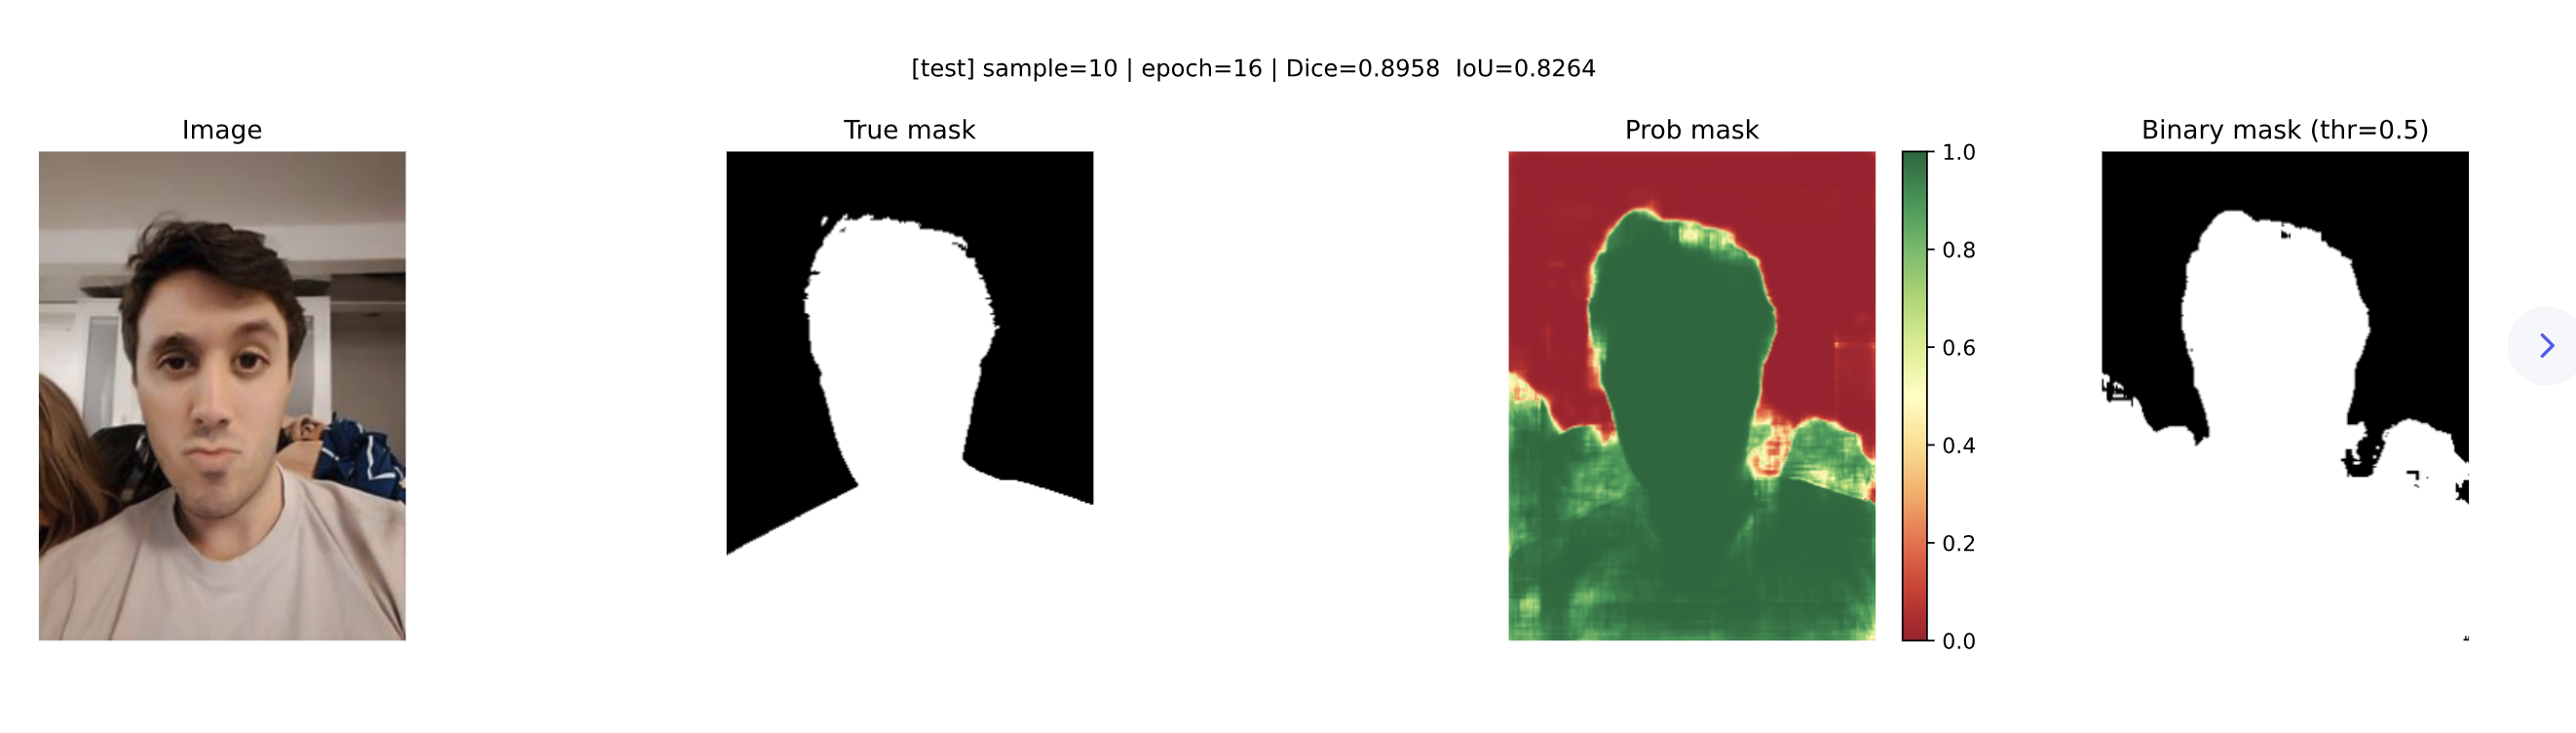

https://www.comet.com/st02230047/image-segmentation-hw/view/new/panels

## `LinkNet (2 балла)`

Реализуйте архитектуру [LinkNet](https://arxiv.org/pdf/1707.03718.pdf) с использованием энкодера, основанного на `VGG13`. Архитектура похожа на `Unet`, но вместо конкатенации слоёв используются skip-connections (сложения). Для реализации достаточно переписать структуру декодировщика из предыдущего пункта.

*Подсказка:* так как конкатенации слоёв заменили на skip-connections, то ожидается, что число параметров стало меньше.

**Обучите сеть и проведите анализ согласно предыдущему пункту. Сравните LinkNet и U-Net по качеству и скорости работы. Сделайте выводы.**

In [ ]:
# your code here

## `Теоретические вопросы (1 балл)`

### `Вопрос 1`
* Сформулируйте два предположения о структуре входных данных, на которые опирается архитектура свёрточных сетей.
* Какие преимущества дает использование сверток в случае, если эти предположения верные?
* Приведите пример входных данных, когда эти предположения не выполняются.

- 1. Локальность, так как соседние элементы (пиксели) сильнее связаны друг с другом, чем далекие.
  2. Инвариантность к сдвигу, так как детектор признака должен работать одинаково для соответствующего паттерна независимо от его местоположения.
- 1. Локальные связи, поскольку каждый нейрон смотрит только на небольшую область входа, что снижает вычислительную нагрузку.
  2. Эквивариантность к сдвигу, поскольку сеть обнаруживает признаки независимо от их позиции.
- Табличные данные, так как по дефолту не задана какая-то пространственная близость между признаками

### `Вопрос 2`
Пусть дано множество 1-D входов ${x^{(i)} \in \mathbb{R}^{100}}$.

Рассмотрим полносвязный слой ${f(\cdot)}$, заданный как ${f(x^{(i)}) = \sigma(Wx^{(i)})}$, где ${W}$ - матрица весов размерности ${1000\times 100}$ и ${\sigma(\cdot)}$ поэлементная функция активации.

Рассмотрим также сверточный слой ${g(\cdot)}$ с десятью картами признаков: ${g(x^{(i)}) = \sigma([z_1, z_2,...,z_{10}])}$, где ${z_j = x^{(i)}\ast w_j}$ для некоторого ядра свертки ${w_j}$ с размером 3 и паддингом 1. Для ${f(\cdot)}$ и ${g(\cdot)}$ напишите:

1. Размерность выходного пространства.
2. Количество обучаемых параметров.
3. Число операций при выполнении forward pass (при условии наивной реализации перемножения матриц и вычисления сверток).

1. - Для f: 1000
   - Для g: 10 * (100 + 2 - 3) + 1 = 1000
2. - Для f: 1000 * 100 = 100000
   - Для g: 10 * 3 = 30
3. - Для f: (100 * (100 + 99)) * 1000 + 1000 = 200000
   - Для g: 10 * 100 * (3 + 2) + 1000 = 6000

## `Бонус: постобработка изображений (1 балл)`

В предложенной задаче на фотографиях необходимо сегментировать только центральное изображение. Артефакты, которые появляются на краях изображения, можно удалять с помощью постобработки (например, с помощью модуля [skimage.morphology](https://scikit-image.org/docs/dev/api/skimage.morphology.html)).

Реализуйте какой-нибудь из методов постобработки, дающий прирост в качестве. Продемонстрируйте несколько изображений, на которых постобработка будет оказывать влияние на результат сегментации.

## `Бонус: существенное улучшение качества (2 балла)`

Придумайте какой-нибудь трюк, который существенно (с учётом бонусного пункта 1) повысит качество (которое должно быть и так достаточно высоко). Не разрешается использовать дополнительные данные или другие предобученные кодировщики кроме VGG13.

Если вы что-то попробовали, но качество не повысилось, всё равно оформите этот пункт, даже за неудачные попытки могут быть начислены баллы.

## `Бонус: обучение с использованием сторонних фреймворков (1 балл)`

Попробуйте обучить свою модель с использованием одного из следующих фреймворков: [catalyst](https://github.com/catalyst-team/catalyst), [pytorch-lightning](https://www.pytorchlightning.ai/), [ignite](https://github.com/pytorch/ignite).

## `Бонус: аугментации (0.5 балла)`

Воспользуйтесь сторонними библиотеками для аугментаций, например, [deepaugment](https://github.com/barisozmen/deepaugment) и [albumentations](https://albumentations.ai/) для улучшения качества модели.

## `Бонус: torch.compile (0.25 балла)`

Попробуйте установить [Pytorch 2.0](https://pytorch.org/get-started/pytorch-2.0/) и запустите обучение с использованием `torch.compile`. Тщательно сравните время с и без использованием компиляции.

*Замечание:* обязательно укажите конфигурацию системы (версия OS, модель CPU/GPU, объём RAM), на которой производилось обучение. В частности, приложите вывод команд:
```bash
! nvcc --version
! nvidia-smi
```